In [11]:
import torch
import torchvision
import torchvision.transforms as transforms

NUM_EPOCHS = 25

In [12]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

In [13]:
# Define CIFAR-10 training dataset
trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Define CIFAR-10 test dataset
testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

In [14]:
# Wrap CIFAR-10 training set in dataloader
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=128,
    shuffle=True,
    num_workers=2
)

# Wrap CIFAR-10 testing set in dataloader
testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=100,
    shuffle=False,
    num_workers=2
)

In [15]:
# Sanity check
print(len(trainset))  # should be 50000
print(len(testset))   # should be 10000

50000
10000


In [16]:
dataiter = iter(trainloader)
images, labels = next(dataiter)

print(images.shape)  # expected: [128, 3, 32, 32]
print(labels.shape)  # expected: [128]

torch.Size([128, 3, 32, 32])
torch.Size([128])


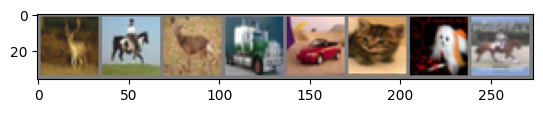

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Utility function to plot images
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

imshow(torchvision.utils.make_grid(images[:8]))

In [18]:
import torchvision.models as models

model = models.resnet18(num_classes=10)

outputs = model(images)
print(outputs.shape)  # expected: [128, 10]

torch.Size([128, 10])


In [19]:
import torchvision.models as models

model = models.resnet18(num_classes=10)

outputs = model(images)
print(outputs.shape)  # expected: [128, 10]

torch.Size([128, 10])


In [20]:
import torch.nn as nn
import torch.optim as optim

# Define loss criterion / optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Place model in training mode
model.train()

# Define main training loop
for epoch in range(1, NUM_EPOCHS+1):
    print("=====================")
    print(f"  EPOCH: {epoch}")
    print("=====================")
    for i, (images, labels) in enumerate(trainloader, 1):
        optimizer.zero_grad()

        # Get model predictions, loss
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        if i % 10 == 0:
            print(f"  Batch: {i} Loss: {loss.item()}")

    # Run model on test set
    test_loss = 0
    for images, labels in testloader:

        # Get model predictions, loss
        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss

    avg_test_loss = test_loss / len(test_loader)
        
        
    
    model.eval()
    print("===============================")
    print(f"End of epoch {epoch} summary:")
    print(f"  Training Loss: {loss.item()}")
    print(f"  Testing Loss:  {avg_test_loss.item()}")
    print("===============================")

  EPOCH: 1
  Batch: 10 Loss: 2.269517660140991
  Batch: 20 Loss: 2.2214248180389404
  Batch: 30 Loss: 1.9910414218902588
  Batch: 40 Loss: 1.998191475868225
  Batch: 50 Loss: 2.0046920776367188
  Batch: 60 Loss: 1.8352192640304565
  Batch: 70 Loss: 1.806837797164917
  Batch: 80 Loss: 1.6797016859054565
  Batch: 90 Loss: 1.86020827293396
  Batch: 100 Loss: 1.6562708616256714
  Batch: 110 Loss: 1.8312718868255615
  Batch: 120 Loss: 1.821096658706665
  Batch: 130 Loss: 1.8137609958648682
  Batch: 140 Loss: 1.5799239873886108
  Batch: 150 Loss: 1.8328192234039307
  Batch: 160 Loss: 1.5051244497299194
  Batch: 170 Loss: 1.5023741722106934
  Batch: 180 Loss: 1.6003283262252808
  Batch: 190 Loss: 1.3813053369522095
  Batch: 200 Loss: 1.6070082187652588
  Batch: 210 Loss: 1.5791938304901123
  Batch: 220 Loss: 1.5078941583633423
  Batch: 230 Loss: 1.627095341682434
  Batch: 240 Loss: 1.5352171659469604
  Batch: 250 Loss: 1.478981852531433


KeyboardInterrupt: 